In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [63]:
def equalize_hist(im, nbr_bins=256):
    """对一幅灰度图像进行直方图均衡化"""
    # 图像直方图统计
    imhist, bins = np.histogram(im.flatten(), nbr_bins)
    # 累积分布函数
    cdf = imhist.cumsum()
    cdf = 255.0 * cdf / cdf[-1]
    # 使用累积分布函数的线性插值，计算新的像素值
    im2 = np.interp(im.flatten(), bins[:-1], cdf)  # 分段线性插值函数
    return im2.reshape(im.shape), cdf

In [64]:
v = cv2.VideoCapture('video/v3.mp4')
if v.isOpened():
    open,frame = v.read()
else:
    open = False

cnt = 1
while open:
    re,frame = v.read()
    if not re:           # 视频结束或读取失败
        break
    frame = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)   #灰度化操作（在imshow之前启用）
    taget_size = (350,240)#(宽,高)
    frame = cv2.resize(frame,taget_size)
    filtered_img = cv2.GaussianBlur(frame,(3,3),0)   #高斯滤波
    img_equalize_hist, cdf = equalize_hist(filtered_img)    #均衡化
    cv2.imshow('result',img_equalize_hist/255.0)
    if cv2.waitKey(25) & 0xFF == 27:
        break
    cnt +=1
    if cnt == 5:
        required_img = img_equalize_hist

cv2.imwrite('image/purpose.png',required_img)
v.release()
cv2.destroyAllWindows()

## 运行的单帧结果
<div align="center">
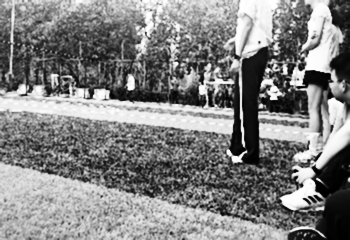
<br>
<b>图1 - 第5帧的结果</b>
</div>

In [ ]:
# 体会与收获：
## 1.学习了并弄懂了多种图像处理的方法，eg.灰度处理，均衡化处理，高斯滤波处理
## 2.对于编程中出现的问题（eg.窗口视频图像过白，而截图画面太黑），查阅具体函数后才发现：
    cv2.imshow：当显示浮点型图像时，OpenCV 默认认为像素值范围是 [0, 1]。所以需要除以255.0
    v2.imwrite：保存浮点型图像时，对于值在 [0, 255] 范围内的浮点数，会直接取整并截断到 0~255，无需除以255.0。
    同时查阅资料发现对于这种格式转化的问题，推荐的是：显式转换为 uint8 类型，避免依赖 OpenCV 的隐式转换。（ps.上述代码未使用。）
## 3.学习了如何在jupyter notebook的markdown网格里插入图片的方式：
    直接复制拖入（无法达到居中的效果）；HTML格式；<div>格式
## 4.复习了部分python语法